# 🥈 도장 2: 절벽 회피 AI — 보상을 바꾸면 행동이 달라진다!

**난이도**: 🥈 중간 (30-40분)

**핵심 메시지**: 같은 Q-Learning 알고리즘이라도 **보상을 어떻게 설계하느냐**에 따라 에이전트의 행동이 완전히 달라집니다.

**CliffWalking-v1 환경**:
- 4x12 격자 (48개 상태), 4개 행동 (위/오른쪽/아래/왼쪽)
- 시작(S)에서 목표(G)까지 이동, 절벽(C)에 빠지면 시작으로 복귀!

---

In [15]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import subprocess
subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], capture_output=True)
fm.fontManager.__init__()  # 폰트 캐시 갱신
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

## 셀 1 — 라이브러리 임포트

In [16]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import random

print('라이브러리 임포트 완료!')

라이브러리 임포트 완료!


## 셀 2 — train_q_learning 함수 정의

도장 1에서 사용한 것과 동일한 함수입니다. 빈칸을 채우세요.

In [17]:
def train_q_learning(env, learning_rate, discount_factor, epsilon, num_episodes):
    n_states = env.observation_space.n   # 상태 수 (CliffWalking: 48)
    n_actions = env.action_space.n       # 행동 수 (CliffWalking: 4)

    q_table = np.zeros((n_states, n_actions))
    rewards_per_episode = []

    for episode in range(num_episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            # Epsilon-greedy policy
            if random.uniform(0, 1) < epsilon:
                action = env.action_space.sample()  # Explore action space
            else:
                action = np.argmax(q_table[state, :])  # Exploit learned values

            next_state, reward, done, truncated, _ = env.step(action)
            # Ensure next_state is an integer for indexing
            if isinstance(next_state, np.ndarray):
                next_state = int(next_state[0])
            else:
                next_state = int(next_state)

            # Q-learning formula
            q_table[state, action] = q_table[state, action] + learning_rate * \
                                     (reward + discount_factor * np.max(q_table[next_state, :]) - q_table[state, action])

            state = next_state
            total_reward += reward

        rewards_per_episode.append(total_reward)

        # Decay epsilon
        epsilon = max(0.01, epsilon * 0.995) # Epsilon decay rate, ensuring it doesn't go below 0.01

    return q_table, rewards_per_episode

print('train_q_learning 함수 정의 완료!')

train_q_learning 함수 정의 완료!


## 셀 3 — 환경 탐색

CliffWalking-v0 환경의 구조를 살펴봅시다.

## CliffWalking-v0 환경 버전 사용시 오류 발생으로인하여 최신 버전인 CliffWalking-v1으로 수정!!!

In [18]:
# 환경 생성
env = gym.make('CliffWalking-v1', render_mode='ansi')  # CliffWalking-v1

print('=== CliffWalking-v1 환경 정보 ===')
print(f'상태 수: {env.observation_space.n}')  # 48개 상태 (4x12 격자)
print(f'행동 수: {env.action_space.n}')       # 4개 행동
print()

print('행동 의미:')
print('  0 = 위')
print('  1 = 오른쪽')
print('  2 = 아래')
print('  3 = 왼쪽')
print()

print('맵 구조: 4행 x 12열')
print('  S = 시작 (왼쪽 아래, 상태 36)')
print('  G = 목표 (오른쪽 아래, 상태 47)')
print('  C = 절벽 (아래 행의 37~46)')
print()

print('보상 구조:')
print('  일반 이동: -1')
print('  절벽에 빠짐: -100 (+ 시작 위치로 복귀)')
print('  목표 도달: -1 (별도 성공 보상 없음)')
print()

state, info = env.reset(seed=42)
print('초기 맵:')
print(env.render())

=== CliffWalking-v1 환경 정보 ===
상태 수: 48
행동 수: 4

행동 의미:
  0 = 위
  1 = 오른쪽
  2 = 아래
  3 = 왼쪽

맵 구조: 4행 x 12열
  S = 시작 (왼쪽 아래, 상태 36)
  G = 목표 (오른쪽 아래, 상태 47)
  C = 절벽 (아래 행의 37~46)

보상 구조:
  일반 이동: -1
  절벽에 빠짐: -100 (+ 시작 위치로 복귀)
  목표 도달: -1 (별도 성공 보상 없음)

초기 맵:
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  C  C  C  C  C  C  C  C  C  C  T




## 셀 4 — 기본 Q-Learning 학습 (3000 에피소드)

In [19]:
# 기본 환경으로 학습
base_env = gym.make('CliffWalking-v1')  # CliffWalking-v1

print('기본 환경으로 학습 중... (3000 에피소드)')
# Q-learning hyper-parameters
learning_rate = 0.1
discount_factor = 0.99
epsilon = 1.0
num_episodes = 3000

q_base, rewards_base = train_q_learning(base_env, learning_rate, discount_factor, epsilon, num_episodes)

print(f'완료! 마지막 100 에피소드 평균 보상: {np.mean(rewards_base[-100:]):.1f}')

기본 환경으로 학습 중... (3000 에피소드)
완료! 마지막 100 에피소드 평균 보상: -16.2


## 셀 5 — 경로 시각화 함수

Q-Table에서 최적 경로를 추출하고 히트맵으로 보여주는 함수입니다.

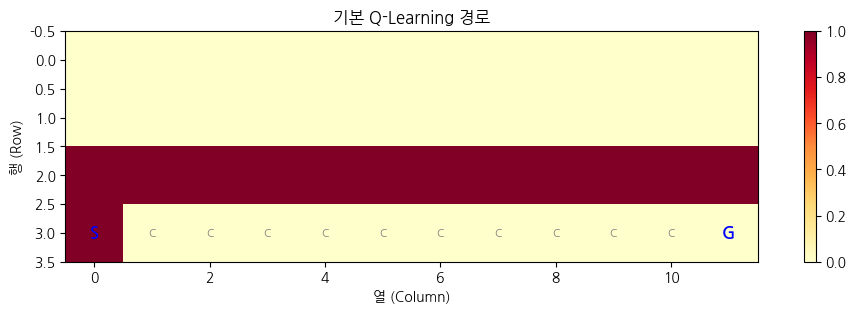

경로 히트맵: 밝은 색일수록 자주 방문한 상태


In [20]:
def get_optimal_path(q_table, max_steps=100):
    env = gym.make('CliffWalking-v1') # 시각화를 위한 환경 생성
    visit_count = np.zeros(q_table.shape[0])
    state, _ = env.reset(seed=42) # 일관된 시각화를 위해 seed 고정
    done = False
    steps = 0

    while not done and steps < max_steps:
        action = np.argmax(q_table[state, :]) # 최적 행동 선택
        visit_count[state] += 1
        next_state, _, done, _, _ = env.step(action)
        state = next_state
        steps += 1
    env.close()
    return visit_count.reshape(4, 12)  # 4x12 격자로 변환


def plot_path(q_table, title, ax):
    """경로 히트맵을 그리는 함수"""
    path_map = get_optimal_path(q_table)
    im = ax.imshow(path_map, cmap='YlOrRd', interpolation='nearest')
    ax.set_title(title)
    ax.set_xlabel('열 (Column)')
    ax.set_ylabel('행 (Row)')
    # S, G, 절벽 표시
    ax.text(0, 3, 'S', ha='center', va='center', fontsize=12, fontweight='bold', color='blue')
    ax.text(11, 3, 'G', ha='center', va='center', fontsize=12, fontweight='bold', color='blue')
    for c in range(1, 11):
        ax.text(c, 3, 'C', ha='center', va='center', fontsize=8, color='gray')
    plt.colorbar(im, ax=ax)


# 기본 학습 결과 경로 시각화
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
plot_path(q_base, '기본 Q-Learning 경로', ax)
plt.tight_layout()
plt.show()

print('경로 히트맵: 밝은 색일수록 자주 방문한 상태')

## 셀 6 — CustomRewardWrapper 만들기

3-4 수업에서 배운 보상 래퍼를 직접 만들어봅시다! 보상 구조를 바꾸면 에이전트 행동이 달라집니다.

In [21]:
class CliffRewardWrapper(gym.Wrapper):  # gym.Wrapper 상속
    def __init__(self, env, cliff_penalty=-100, step_penalty=-1, goal_reward=0):
        super().__init__(env)
        self.cliff_penalty = cliff_penalty
        self.step_penalty = step_penalty
        self.goal_reward = goal_reward

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        # 환경에서 정의된 보상을 가져옵니다.
        # CliffWalking-v1 환경의 기본 보상 구조를 파악하고 수정합니다.
        # 기본 환경에서는:
        #   일반 이동: -1
        #   절벽: -100 (그리고 시작 위치로 복귀)
        #   목표: -1 (목표 도달 시 게임 종료, 추가 보상 없음)

        new_reward = self.step_penalty # 모든 이동에 기본적으로 주는 패널티

        # 절벽에 빠졌는지 확인 (obs가 시작 위치 36으로 돌아왔고, 기존 reward가 -100인 경우)
        # CliffWalking-v1의 경우, 절벽에 빠지면 reward가 -100이고 state가 36(시작)으로 리셋됩니다.
        if reward == -100: # 기존 환경의 절벽 보상 감지
            new_reward = self.cliff_penalty

        # 목표에 도달했는지 확인 (state가 47이고 게임이 종료된 경우)
        # CliffWalking-v1의 경우, 목표 도달 시 reward는 -1이며, terminated가 True가 됩니다.
        # 이때, obs는 목표 상태(47)가 됩니다.
        if terminated and obs == 47: # 목표 상태에 도달하고 게임 종료
            # 절벽에 빠진 후 종료되는 경우와 구분해야 함.
            # 여기서는 목표에 성공적으로 도달했을 때만 goal_reward를 추가합니다.
            # (절벽에 빠지면 state가 36으로 리셋되므로, obs==47일 경우 목표 도달로 간주)
            new_reward = self.goal_reward # 목표 보상 적용

        return obs, new_reward, terminated, truncated, info

print('CliffRewardWrapper 정의 완료!')
print('이제 보상을 자유롭게 바꿀 수 있습니다!')

CliffRewardWrapper 정의 완료!
이제 보상을 자유롭게 바꿀 수 있습니다!


## 셀 7 — 보상 설계 3종 비교 학습

3가지 서로 다른 보상 설계로 학습하고 결과를 비교합니다.

| 설계 | 절벽 패널티 | 이동 패널티 | 목표 보상 | 예상 행동 |
|------|------------|-----------|----------|----------|
| 기본 | -100 | -1 | 0 | 적당히 안전한 경로 |
| 약한 절벽 | -10 | -1 | 0 | 빠른 길 선호 (절벽 옆도 OK) |
| 강한 절벽 + 목표 보상 | -500 | -1 | +50 | 안전한 경로 선호 |

In [22]:
# 설계 1: 기본 보상 (이미 학습 완료 → q_base, rewards_base)
print('설계 1 (기본): cliff=-100, step=-1, goal=0 → 이미 학습 완료')

# 설계 2: 약한 절벽 패널티
print('설계 2 (약한 절벽) 학습 중...')
weak_env = gym.make('CliffWalking-v1')
weak_env = CliffRewardWrapper(weak_env, cliff_penalty=-10, step_penalty=-1, goal_reward=0)
q_weak, rewards_weak = train_q_learning(weak_env, learning_rate, discount_factor, epsilon, num_episodes)
print(f'  완료! 마지막 100 에피소드 평균: {np.mean(rewards_weak[-100:]):.1f}')

# 설계 3: 강한 절벽 패널티 + 목표 보상
print('설계 3 (강한 절벽 + 목표 보상) 학습 중...')
strong_env = gym.make('CliffWalking-v1')
strong_env = CliffRewardWrapper(strong_env, cliff_penalty=-500, step_penalty=-1, goal_reward=50)
q_strong, rewards_strong = train_q_learning(strong_env, learning_rate, discount_factor, epsilon, num_episodes)
print(f'  완료! 마지막 100 에피소드 평균: {np.mean(rewards_strong[-100:]):.1f}')

print('\n모든 학습 완료!')

설계 1 (기본): cliff=-100, step=-1, goal=0 → 이미 학습 완료
설계 2 (약한 절벽) 학습 중...
  완료! 마지막 100 에피소드 평균: -12.5
설계 3 (강한 절벽 + 목표 보상) 학습 중...
  완료! 마지막 100 에피소드 평균: 35.8

모든 학습 완료!


## 셀 8 — 학습 곡선 비교

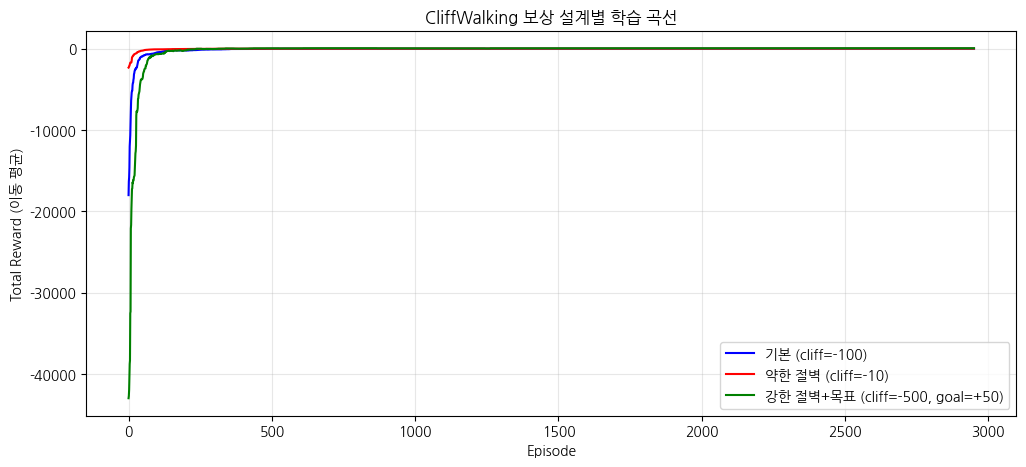

In [23]:
def moving_average(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 5))
plt.plot(moving_average(rewards_base), label='기본 (cliff=-100)', color='blue')
plt.plot(moving_average(rewards_weak), label='약한 절벽 (cliff=-10)', color='red')        # rewards_weak
plt.plot(moving_average(rewards_strong), label='강한 절벽+목표 (cliff=-500, goal=+50)', color='green')  # rewards_strong
plt.xlabel('Episode')
plt.ylabel('Total Reward (이동 평균)')
plt.title('CliffWalking 보상 설계별 학습 곡선')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 셀 9 — 3개 경로 시각화 비교

보상 설계에 따라 에이전트가 선택하는 경로가 어떻게 다른지 확인!

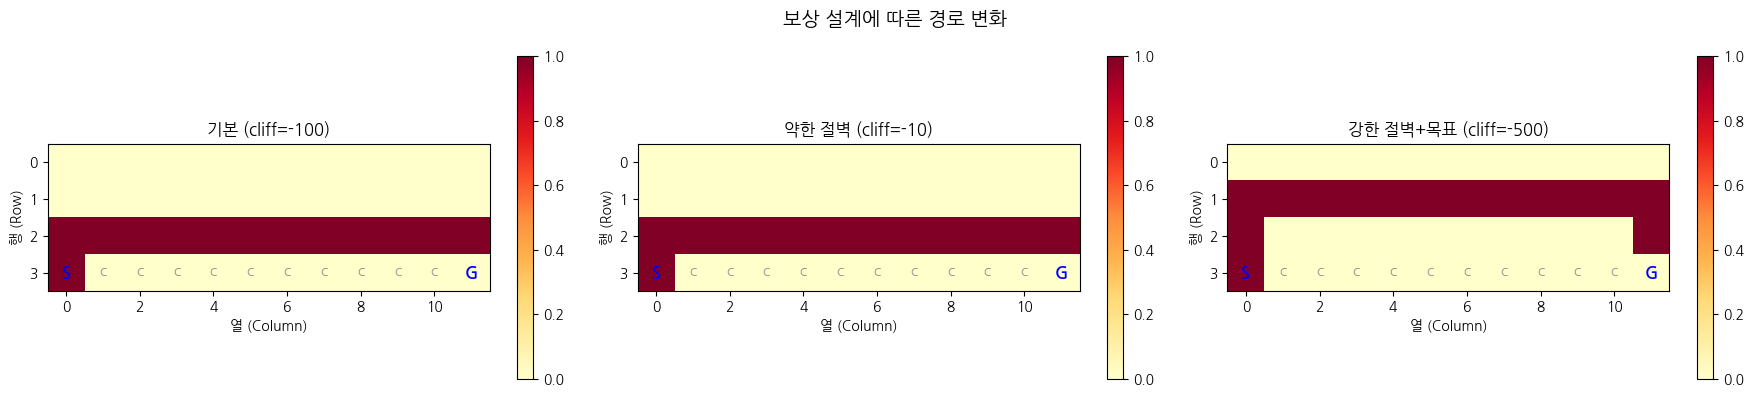

관찰 포인트:
  - 약한 절벽: 절벽 바로 위를 따라가는 최단 경로 (위험하지만 빠름)
  - 강한 절벽: 절벽을 멀리 돌아가는 안전한 경로 (느리지만 안전)
  → 보상을 바꾸면 행동이 달라진다!


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

plot_path(q_base, '기본 (cliff=-100)', axes[0])            # q_base
plot_path(q_weak, '약한 절벽 (cliff=-10)', axes[1])        # q_weak
plot_path(q_strong, '강한 절벽+목표 (cliff=-500)', axes[2])  # q_strong

plt.suptitle('보상 설계에 따른 경로 변화', fontsize=14)
plt.tight_layout()
plt.show()

print('관찰 포인트:')
print('  - 약한 절벽: 절벽 바로 위를 따라가는 최단 경로 (위험하지만 빠름)')
print('  - 강한 절벽: 절벽을 멀리 돌아가는 안전한 경로 (느리지만 안전)')
print('  → 보상을 바꾸면 행동이 달라진다!')

## 셀 10 — 성능 테스트

In [25]:
def test_agent(q_table, label, n_test=100):
    """원래 환경(기본 보상)에서 에이전트 성능 테스트"""
    test_env = gym.make('CliffWalking-v1') # Deprecated v0 -> v1으로 변경
    test_rewards = []

    for _ in range(n_test):
        state, _ = test_env.reset()
        total_reward = 0
        done = False

        while not done:
            action = np.argmax(q_table[state, :]) # 최적 행동 선택
            state, reward, done, _, _ = test_env.step(action)
            total_reward += reward

        test_rewards.append(total_reward)

    avg = np.mean(test_rewards)
    print(f'{label}: 평균 보상 = {avg:.1f}')
    return avg


print('=== 원래 환경에서 성능 비교 (100 에피소드) ===')
avg_base = test_agent(q_base, '기본 (cliff=-100)')
avg_weak = test_agent(q_weak, '약한 절벽 (cliff=-10)')
avg_strong = test_agent(q_strong, '강한 절벽+목표 (cliff=-500, goal=+50)')

=== 원래 환경에서 성능 비교 (100 에피소드) ===
기본 (cliff=-100): 평균 보상 = -13.0
약한 절벽 (cliff=-10): 평균 보상 = -13.0
강한 절벽+목표 (cliff=-500, goal=+50): 평균 보상 = -15.0


## ✅ 도장 획득 체크!

3가지 보상 설계에서 모두 평균 보상 > -20 이면 🥈 도장 획득!

In [26]:
# 도장 체크
if avg_base > -20:
    print("✅ 통과!")
else:
    print("⚠️ 아직 부족합니다. 에피소드를 늘리거나 하이퍼파라미터를 조정해보세요.")
if avg_weak > -20:
    print("✅ 통과!")
else:
    print("⚠️ 아직 부족합니다. 에피소드를 늘리거나 하이퍼파라미터를 조정해보세요.")
if avg_strong > -20:
    print("✅ 통과!")
else:
    print("⚠️ 아직 부족합니다. 에피소드를 늘리거나 하이퍼파라미터를 조정해보세요.")

print('=' * 50)
print('🥈 도장 2 획득! 절벽 회피 AI 완성!')
print('=' * 50)
print()
print('핵심 배운 점:')
print('  같은 알고리즘이라도 보상 설계에 따라 행동이 달라진다!')
print('  - 약한 절벽 패널티 → 빠르지만 위험한 경로')
print('  - 강한 절벽 패널티 → 느리지만 안전한 경로')
print('  보상 설계 = AI의 가치관 설계!')
print()
print('다음 도장: 🥇 블랙잭 AI (Q-Table도 바꿔야 한다!)')

✅ 통과!
✅ 통과!
✅ 통과!
🥈 도장 2 획득! 절벽 회피 AI 완성!

핵심 배운 점:
  같은 알고리즘이라도 보상 설계에 따라 행동이 달라진다!
  - 약한 절벽 패널티 → 빠르지만 위험한 경로
  - 강한 절벽 패널티 → 느리지만 안전한 경로
  보상 설계 = AI의 가치관 설계!

다음 도장: 🥇 블랙잭 AI (Q-Table도 바꿔야 한다!)
